# All Sea Around Us EEZs — PPR validation (TE = 0.1)

Every official EEZ unit is retained. Earlier spatial selection rules are **flags only**, not filters or replacements. EEZ, LME and High Seas are overlapping analysis systems and their totals must not be added together.

The approved 1995 trophic-chain calculation is `SPPR = 10**(TL-1)` and `PPR = catch tonnes × SPPR`. No alternative 2020 regression is used; the 2020 supplement supplies MeanTL only. The separate /9 carbon conversion remains off. Commercial and functional outputs include both correct aggregation and the intentional catch-weighted-TL Jensen shortcut.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd()
if not (ROOT/'eez_output/tables').exists():
    ROOT = ROOT.parent
TABLES = ROOT/'eez_output/tables'
metadata = json.loads((TABLES/'run_metadata.json').read_text())
summary = pd.read_csv(TABLES/'eez_summary.csv')
print(f"{metadata['unit_count']} EEZs | year {metadata['year']} | TE={metadata['transfer_efficiency']}")
assert metadata['transfer_efficiency'] == 0.1
display(summary[['unit_id','region_name','total_catch_tonnes','ppr_species','fraction_eez_ppr']].head(20))

282 EEZs | year 2019 | TE=0.1


,unit_id,region_name,total_catch_tonnes,ppr_species,fraction_eez_ppr
0,EEZ_156,China,9.568141e+06,6.165829e+09,0.092800
1,EEZ_649,Russia (Far East),7.341977e+06,4.411198e+09,0.066392
2,EEZ_704,Viet Nam,5.148305e+06,4.395854e+09,0.066161
3,EEZ_390,Japan (main islands),5.962290e+06,2.997127e+09,0.045109
4,EEZ_604,Peru,6.008753e+06,2.417258e+09,0.036381
5,EEZ_356,India (mainland),4.344032e+06,2.254375e+09,0.033930
6,EEZ_361,Indonesia (Eastern),3.382554e+06,2.093543e+09,0.031509
7,EEZ_959,"USA (Alaska, Subarctic)",2.640185e+06,1.781327e+09,0.026810
8,EEZ_941,Kiribati (Gilbert Islands),5.999628e+05,1.552446e+09,0.023365
9,EEZ_938,Indonesia (Indian Ocean),2.112708e+06,1.549538e+09,0.023322


## Common year, empty archives and catch reconciliation

In [2]:
years = pd.read_csv(TABLES/'year_availability.csv')
display(years.groupby(['first_year','last_year','source_data_status'],dropna=False).size().rename('units').reset_index())
assert years.loc[years.constrains_common_year,'contains_selected_year'].all()
audit = pd.read_csv(TABLES/'ingestion_audit.csv')
assert audit.reconciled.all()
print('Largest catch reconciliation difference (tonnes):',audit.difference_tonnes.abs().max())
display(summary.loc[summary.total_catch_tonnes==0,['unit_id','region_name']])
print('Empty official source archives are retained and do not constrain common year; zero-catch TL coverage is undefined.')

,first_year,last_year,source_data_status,units
0,1950,2019,available,277
1,1951,2019,available,1
2,1952,2019,available,3
3,2004,2019,available,1


Largest catch reconciliation difference (tonnes): 1.862645149230957e-09


,unit_id,region_name


Empty official source archives are retained and do not constrain common year; zero-catch TL coverage is undefined.


## Trophic-level matching coverage

In [3]:
coverage = pd.read_csv(TABLES/'tl_coverage.csv')
routes = coverage.groupby(['match_method','tl_source','match_confidence'],as_index=False).agg(catch_tonnes=('catch_tonnes','sum'),taxa_rows=('taxa_count','sum'))
routes['catch_fraction_eez'] = routes.catch_tonnes / summary.total_catch_tonnes.sum()
display(routes)
display(summary.nsmallest(15,'catch_tl_coverage_fraction')[['unit_id','region_name','catch_tl_coverage_fraction','missing_tl_catch_tonnes']])
print('Overall matched catch fraction:',summary.matched_catch_tonnes.sum()/summary.total_catch_tonnes.sum())

,match_method,tl_source,match_confidence,catch_tonnes,taxa_rows,catch_fraction_eez
0,exact_2020_supplement,2020 supplement MeanTL,high,4.826815e+07,12531,0.469298
1,exact_sea_around_us,Sea Around Us exploited organisms,high,5.458362e+07,11692,0.530702


,unit_id,region_name,catch_tl_coverage_fraction,missing_tl_catch_tonnes
0,EEZ_156,China,1.0,0.0
1,EEZ_649,Russia (Far East),1.0,0.0
2,EEZ_704,Viet Nam,1.0,0.0
3,EEZ_390,Japan (main islands),1.0,0.0
4,EEZ_604,Peru,1.0,0.0
5,EEZ_356,India (mainland),1.0,0.0
6,EEZ_361,Indonesia (Eastern),1.0,0.0
7,EEZ_959,"USA (Alaska, Subarctic)",1.0,0.0
8,EEZ_941,Kiribati (Gilbert Islands),1.0,0.0
9,EEZ_938,Indonesia (Indian Ocean),1.0,0.0


Overall matched catch fraction: 1.0


## Correct versus intentional Jensen aggregation

,classification,ppr_correct,ppr_jensen,underestimate_fraction
0,commercial,6.644218e+10,5.164841e+10,0.222656
1,functional,6.644218e+10,5.684772e+10,0.144403


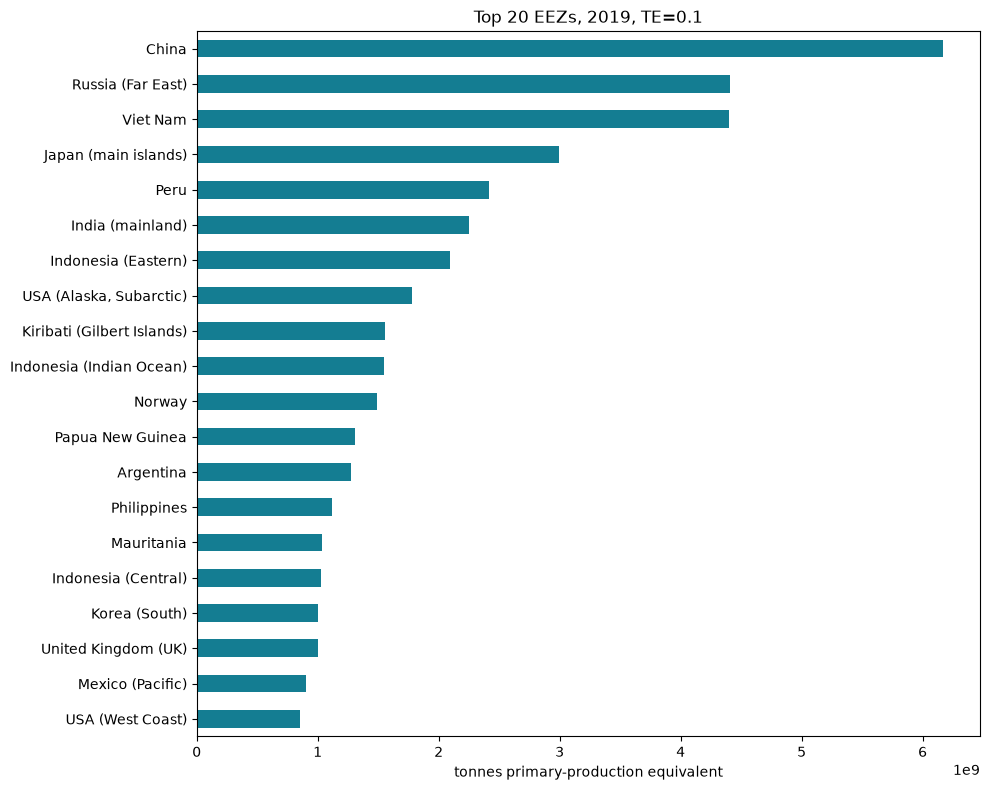

In [4]:
jensen = pd.read_csv(TABLES/'jensen_comparison.csv')
valid = jensen.dropna(subset=['ppr_jensen'])
assert (valid.ppr_correct+1e-6 >= valid.ppr_jensen).all()
bias = jensen.groupby('classification',as_index=False).agg(ppr_correct=('ppr_correct','sum'),ppr_jensen=('ppr_jensen','sum'))
bias['underestimate_fraction'] = 1-bias.ppr_jensen/bias.ppr_correct
display(bias)
top = summary.head(20).sort_values('ppr_species')
ax = top.plot.barh(x='region_name',y='ppr_species',legend=False,figsize=(10,8),color='#147D92')
ax.set_xlabel('tonnes primary-production equivalent'); ax.set_ylabel('')
ax.set_title(f"Top 20 EEZs, {metadata['year']}, TE=0.1")
plt.tight_layout(); plt.show()

## Advisory spatial rules

- Addition: intersection with the **union of LMEs** is strictly below 10% of the EEZ area.
- Preference candidate: at least 90% of the LME lies in the EEZ, and EEZ/LME area ratio is at least 1.20.
- Review flag: the same containment condition, with area ratio at least 1.10 and below 1.20.

The configured containment interpretation is provisional. These values describe this run, not fixed defaults. All exact pairwise fractions are provided. Different pairs can trigger both preference and review flags for one EEZ. Small geographic overlap does not imply small catch overlap.

In [5]:
spatial = json.loads((TABLES/'spatial_validation.json').read_text())
flags = pd.read_csv(TABLES/'eez_selection_flags.csv')
pairs = pd.read_csv(TABLES/'eez_lme_intersections.csv')
print('Thresholds:',spatial['thresholds'])
print('Counts:',spatial['flag_counts'])
print('Area method:',spatial['area_method'])
print('Newly repaired EEZ geometries:',spatial['new_eez_repair_count'])
print('EEZ sum minus union area (km²):',spatial['eez_sum_minus_union_area_km2'])
display(pairs.loc[pairs.flag_prefer_eez_candidate | pairs.flag_review_110_120])
display(flags.loc[flags.flag_add_low_lme_overlap].head(20))

Thresholds: {'low_overlap_threshold': 0.1, 'containment_threshold': 0.9, 'prefer_ratio': 1.2, 'review_ratio': 1.1}
Counts: {'flag_add_low_lme_overlap': 68, 'flag_prefer_eez_candidate': 9, 'flag_review_110_120': 0}
Area method: WGS84 ellipsoidal cylindrical equal-area; linear lon/lat edges densified <=0.05 degrees; geodesic cross-check in <=90-degree longitude sectors
Newly repaired EEZ geometries: 147
EEZ sum minus union area (km²): 5192075.485771835


,eez_unit_id,eez_name,lme_unit_id,lme_name,eez_area_km2,lme_area_km2,intersection_km2,intersection_fraction_of_eez,intersection_fraction_of_lme,eez_to_lme_area_ratio,lme_mostly_contained,flag_prefer_eez_candidate,flag_review_110_120
7,EEZ_036,Australia,LME_039,North Australian Shelf,6.329385e+06,7.792338e+05,7.745406e+05,0.122372,0.993977,8.122576,True,True,False
8,EEZ_036,Australia,LME_040,Northeast Australian Shelf-Great Barrier Reef,6.329385e+06,1.281813e+06,1.274246e+06,0.201322,0.994097,4.937839,True,True,False
9,EEZ_036,Australia,LME_041,East-Central Australian Shelf,6.329385e+06,6.519547e+05,6.154822e+05,0.097242,0.944057,9.708320,True,True,False
10,EEZ_036,Australia,LME_042,Southeast Australian Shelf,6.329385e+06,1.191816e+06,1.188631e+06,0.187796,0.997328,5.310709,True,True,False
11,EEZ_036,Australia,LME_043,Southwest Australian Shelf,6.329385e+06,1.014951e+06,1.012369e+06,0.159947,0.997456,6.236148,True,True,False
12,EEZ_036,Australia,LME_044,West-Central Australian Shelf,6.329385e+06,5.793568e+05,5.784178e+05,0.091386,0.998379,10.924848,True,True,False
13,EEZ_036,Australia,LME_045,Northwest Australian Shelf,6.329385e+06,9.108425e+05,8.458689e+05,0.133642,0.928667,6.948935,True,True,False
23,EEZ_076,Brazil (mainland),LME_015,South Brazil Shelf,2.412664e+06,5.665796e+05,5.576099e+05,0.231118,0.984169,4.258297,True,True,False
68,EEZ_234,Faeroe Isl. (Denmark),LME_060,Faroe Plateau,2.720764e+05,1.041868e+05,1.029618e+05,0.378430,0.988243,2.611430,True,True,False
182,EEZ_649,Russia (Far East),LME_052,Sea of Okhotsk,3.394719e+06,1.563893e+06,1.480328e+06,0.436068,0.946566,2.170686,True,True,False


,unit_id,eez_unit_id,eez_name,sau_region_id,area_km2,lme_union_intersection_km2,lme_overlap_fraction_of_eez,hs_union_intersection_km2,hs_overlap_fraction_of_eez,uncovered_by_lme_or_hs_km2,...,flag_add_low_lme_overlap,flag_prefer_eez_candidate,flag_review_110_120,prefer_eez_lme_ids,review_110_120_lme_ids,mostly_contained_lme_ids,mostly_contained_lme_count,max_lme_containment_fraction,max_eez_to_lme_area_ratio,max_eez_to_mostly_contained_lme_area_ratio
2,EEZ_016,EEZ_016,American Samoa,16,4.040961e+05,0.000000,0.000000,0.000000,0.000000,4.040961e+05,...,True,False,False,NaN,NaN,NaN,0,0.000000,0.000000,0.0
4,EEZ_028,EEZ_028,Antigua & Barbuda,28,1.110559e+05,3710.240370,0.033409,600.408107,0.005406,1.067452e+05,...,True,False,False,NaN,NaN,NaN,0,0.001137,0.034039,0.0
7,EEZ_037,EEZ_037,Macquarie Isl. (Australia),37,4.760099e+05,0.000000,0.000000,578.504169,0.001215,4.754314e+05,...,True,False,False,NaN,NaN,NaN,0,0.000000,0.000000,0.0
8,EEZ_038,EEZ_038,Lord Howe Isl. (Australia),38,5.411480e+05,33748.080844,0.062364,487.284314,0.000900,5.069128e+05,...,True,False,False,NaN,NaN,NaN,0,0.051764,0.830039,0.0
14,EEZ_060,EEZ_060,Bermuda (UK),60,4.503023e+05,0.000000,0.000000,19.256458,0.000043,4.502831e+05,...,True,False,False,NaN,NaN,NaN,0,0.000000,0.000000,0.0
16,EEZ_074,EEZ_074,Bouvet Isl. (Norway),74,4.411414e+05,0.000000,0.000000,42.107496,0.000095,4.410993e+05,...,True,False,False,NaN,NaN,NaN,0,0.000000,0.000000,0.0
18,EEZ_077,EEZ_077,Trindade & Martim Vaz Isl. (Brazil),77,4.685343e+05,0.000000,0.000000,14.202724,0.000030,4.685201e+05,...,True,False,False,NaN,NaN,NaN,0,0.000000,0.000000,0.0
20,EEZ_086,EEZ_086,Chagos Archipelago (UK),86,6.373382e+05,0.000000,0.000000,848.823277,0.001332,6.364894e+05,...,True,False,False,NaN,NaN,NaN,0,0.000000,0.000000,0.0
21,EEZ_090,EEZ_090,Solomon Isl.,90,1.598531e+06,199.935326,0.000125,3.088121,0.000002,1.598328e+06,...,True,False,False,NaN,NaN,NaN,0,0.000156,1.247086,0.0
22,EEZ_092,EEZ_092,British Virgin Isl. (UK),92,8.097383e+04,1653.925646,0.020425,170.300016,0.002103,7.914960e+04,...,True,False,False,NaN,NaN,NaN,0,0.000507,0.024819,0.0


## Separate spatial-system summaries — not additive

In [6]:
all_areas = pd.read_csv(TABLES/'all_areas_summary.csv')
display(all_areas.groupby('region_type').agg(units=('unit_id','size'),catch_tonnes=('total_catch_tonnes','sum'),ppr=('ppr_species','sum')))
assert all_areas.year.nunique()==1
assert np.allclose(all_areas.groupby('region_type').fraction_type_ppr.sum(),1)
print('All Areas Summary ranks and fractions are within each spatial system. There is no mixed EEZ+LME+HS world total.')

,units,catch_tonnes,ppr
region_type,,,
EEZ,282,1.028518e+08,6.644218e+10
High Seas,18,3.822570e+06,7.375990e+09
LME,66,9.529312e+07,5.787669e+10


All Areas Summary ranks and fractions are within each spatial system. There is no mixed EEZ+LME+HS world total.


## Independent final verification

In [7]:
sys.path.insert(0,str(ROOT/'tools'))
from validate_eez_release import validate
report = validate(ROOT,workbooks=True)
print(json.dumps(report,indent=2))
assert report['status']=='passed'
print('All scientific, spatial and exported workbook checks passed.')

{
  "status": "passed",
  "year": 2019,
  "transfer_efficiency": 0.1,
  "eez_count": 282,
  "species_rows": 24223,
  "empty_catch_units": [],
  "catch_tonnes_sum_across_eezs": 102851768.50340083,
  "ppr_sum_across_eezs": 66442175603.651695,
  "catch_tl_coverage_fraction": 1.0,
  "missing_tl_catch_tonnes": 0.0,
  "flag_counts": {
    "flag_add_low_lme_overlap": 68,
    "flag_prefer_eez_candidate": 9,
    "flag_review_110_120": 0
  },
  "jensen_violation_count": 0,
  "totals_by_spatial_type_not_additive": [
    {
      "region_type": "EEZ",
      "units": 282,
      "catch_tonnes": 102851768.50340083,
      "ppr": 66442175603.651695
    },
    {
      "region_type": "High Seas",
      "units": 18,
      "catch_tonnes": 3822569.553296488,
      "ppr": 7375989643.959514
    },
    {
      "region_type": "LME",
      "units": 66,
      "catch_tonnes": 95293115.71073358,
      "ppr": 57876694349.93465
    }
  ],
  "workbook_count": 283,
  "formula_count": 104954,
  "formula_errors": 0
}
All 

## Sources and scope limits

- [Sea Around Us definitions](https://www.seaaroundus.org/sea-around-us-area-parameters-and-definitions/): analytical EEZs may be divided by ocean-facing coast or territory; mapped boundaries are not legal authority.
- [Catch reconstruction and allocation](https://www.seaaroundus.org/catch-reconstruction-and-allocation-methods/): catches are not uniformly distributed by area. No area-based catch subtraction is performed here.
- [Sea Around Us downloads](https://www.seaaroundus.org/tools-guide/).
- Pauly & Christensen (1995), *Nature* 374, 255–257; supplied 2020 supplement MeanTL.

Source ZIPs retain all available years. Tables and workbooks calculate the configurable common analysis year. Geometry repairs, normalized dateline layers, input hashes and source URLs are included in the release. This run gathers all data for later selection; it does not construct a disjoint final world partition.